In [ ]:
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
!tar -xzvf ta-lib-0.4.0-src.tar.gz
%cd ta-lib
!./configure --prefix=/usr
!make
!make install
!pip install Ta-Lib

--2024-12-26 05:21:31--  http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
Resolving prdownloads.sourceforge.net (prdownloads.sourceforge.net)... 104.18.13.149, 104.18.12.149, 2606:4700::6812:d95, ...
Connecting to prdownloads.sourceforge.net (prdownloads.sourceforge.net)|104.18.13.149|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz [following]
--2024-12-26 05:21:31--  http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz
Resolving downloads.sourceforge.net (downloads.sourceforge.net)... 104.18.13.149, 104.18.12.149, 2606:4700::6812:c95, ...
Reusing existing connection to prdownloads.sourceforge.net:80.
HTTP request sent, awaiting response... 302 Found
Location: http://nchc.dl.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz?viasf=1 [following]
--2024-12-26 05:21:32--  http://nchc.dl.sourceforge.

In [ ]:
import talib as ta
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Configuration variables
ticker = 'BTC-USD'
sequence_length = 60
train_ratio = 0.8
epochs = 100


In [ ]:
btc_data = yf.download(ticker, start='2015-01-01', end='2024-01-01')
btc_data.columns = btc_data.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


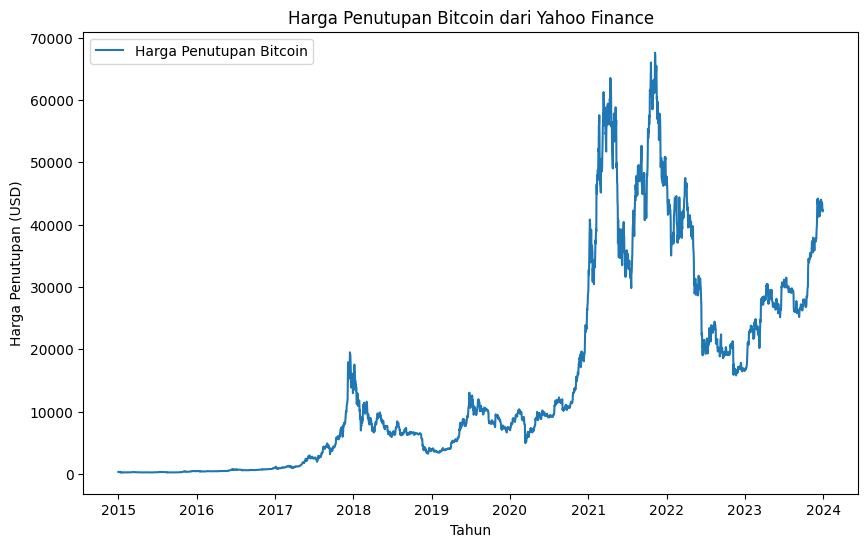

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(btc_data['Close'], label='Harga Penutupan Bitcoin')
plt.title('Harga Penutupan Bitcoin dari Yahoo Finance')
plt.xlabel('Tahun')
plt.ylabel('Harga Penutupan (USD)')
plt.legend()
plt.show()

In [ ]:
btc_data['EMA'] = ta.EMA(btc_data['Close'], timeperiod=100)
btc_data['MA'] = ta.SMA(btc_data['Close'], timeperiod=200)

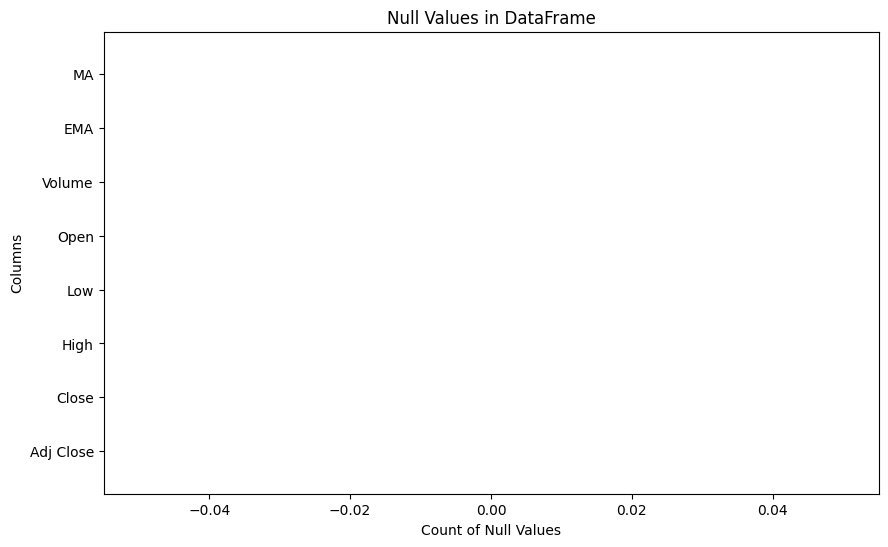

In [ ]:
btc_data = btc_data.dropna()
data_to_scale = btc_data[['Close', 'EMA', 'MA']]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_to_scale)

null_values = btc_data.isnull().sum()
plt.figure(figsize=(10, 6))
plt.barh(btc_data.columns, null_values.values, color='red')
plt.title('Null Values in DataFrame')
plt.xlabel('Count of Null Values')
plt.ylabel('Columns')
plt.show()

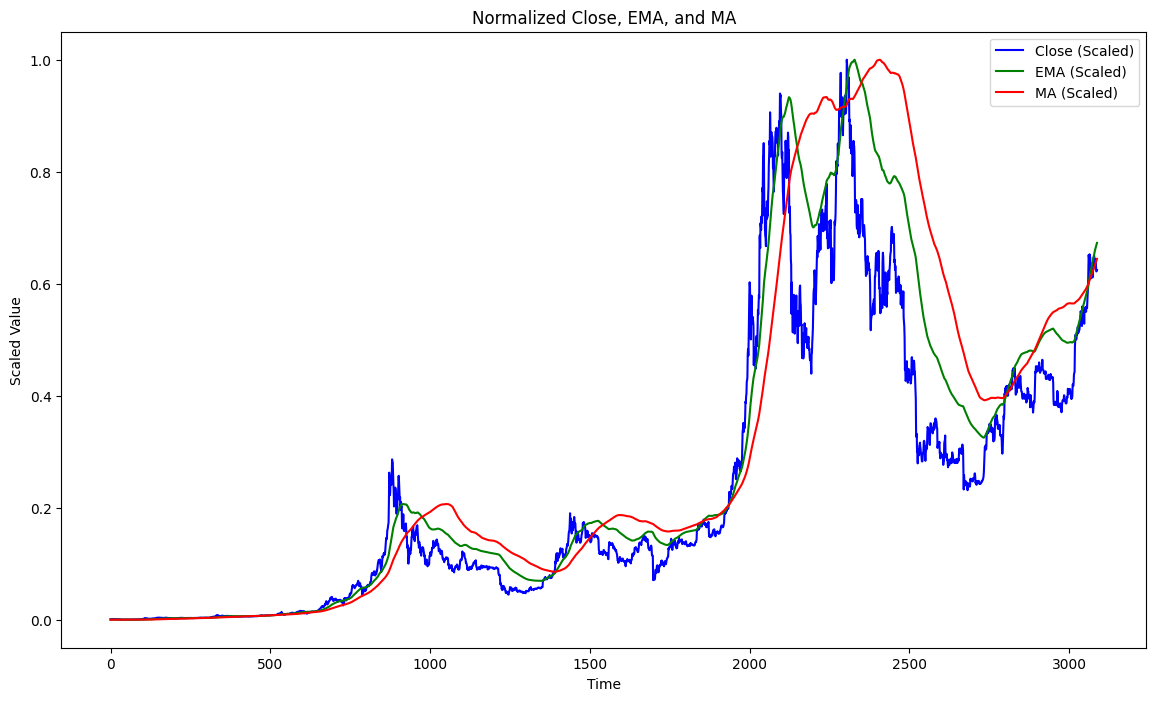

In [ ]:
scaled_df = pd.DataFrame(scaled_data, columns=data_to_scale.columns)
plt.figure(figsize=(14, 8))
plt.plot(scaled_df['Close'], label='Close (Scaled)', color='blue')
plt.plot(scaled_df['EMA'], label='EMA (Scaled)', color='green')
plt.plot(scaled_df['MA'], label='MA (Scaled)', color='red')
plt.title('Normalized Close, EMA, and MA')
plt.xlabel('Time')
plt.ylabel('Scaled Value')
plt.legend()
plt.show()

In [ ]:
training_data_len = int(np.ceil(train_ratio * len(scaled_data)))
train_data = scaled_data[:training_data_len]
test_data = scaled_data[training_data_len - sequence_length:]

In [ ]:
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data, sequence_length)
X_test, y_test = create_dataset(test_data, sequence_length)

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - loss: 0.0153
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0027
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - loss: 0.0021
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0016
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 0.0015
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - loss: 0.0019
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 0.0015
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0013
Epoch 9/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.0014
Epoch 10/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0014
Epoch 11/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0014
Epoch 12/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0011
Epoch 13/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0014
Epoch 14/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0012
Epoch 15/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - l

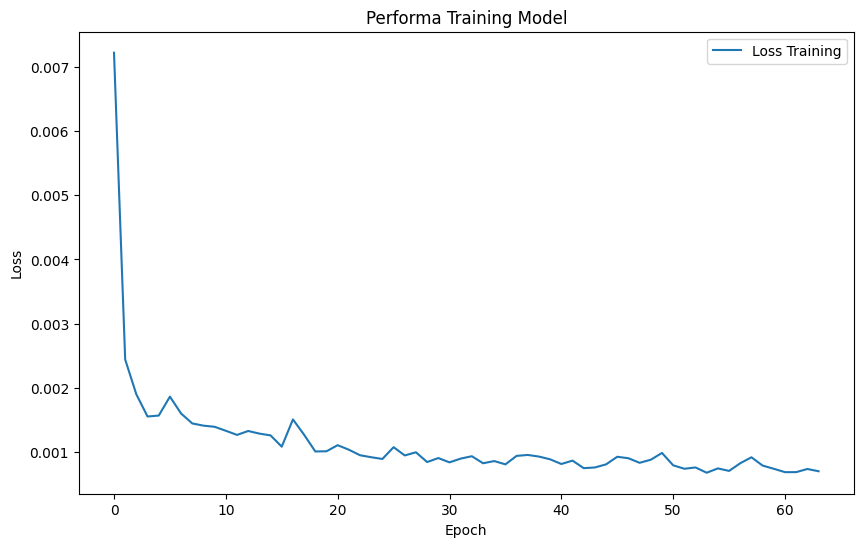

In [ ]:
# Build and compile the model
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])
model.compile(optimizer='adam', loss='mean_squared_error')

# Early stopping callback
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(X_train, y_train, epochs=epochs, batch_size=32, callbacks=[early_stopping])

# Visualize loss during training
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Loss Training')
plt.title('Performa Training Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
predicted_prices = model.predict(X_test)
predicted_prices_extended = np.zeros((predicted_prices.shape[0], 3))
predicted_prices_extended[:, 0] = predicted_prices[:, 0]
predicted_prices_original_scale = scaler.inverse_transform(predicted_prices_extended)[:, 0]

y_test_extended = np.zeros((y_test.shape[0], 3))
y_test_extended[:, 0] = y_test
y_test_actual_original_scale = scaler.inverse_transform(y_test_extended)[:, 0]

mse = mean_squared_error(y_test_actual_original_scale, predicted_prices_original_scale)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual_original_scale, predicted_prices_original_scale)
mape = mean_absolute_percentage_error(y_test_actual_original_scale, predicted_prices_original_scale)
accuracy = 100 - (mape * 100)

print(f'Akurasi: {accuracy:.2f}%')
print(f'MAPE: {mape * 100:.2f}%')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Error (MAE): {mae}')


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Akurasi: 94.39%
MAPE: 5.61%
Mean Squared Error (MSE): 2984359.607623025
Root Mean Squared Error (RMSE): 1727.5299151166746
Mean Absolute Error (MAE): 1459.1862834514072


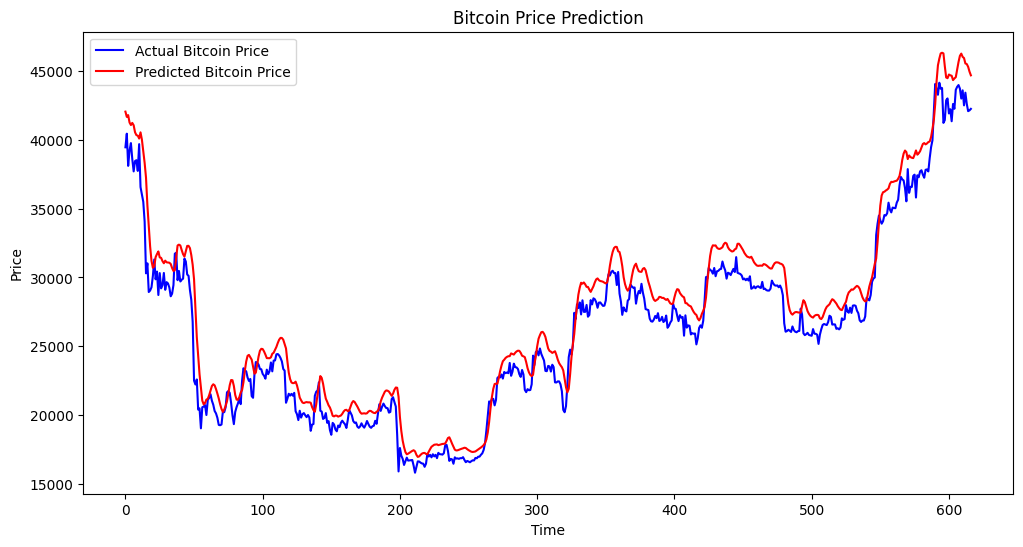

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual_original_scale, color='blue', label='Actual Bitcoin Price')
plt.plot(predicted_prices_original_scale, color='red', label='Predicted Bitcoin Price')
plt.title('Bitcoin Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

[*********************100%***********************]  1 of 1 completed

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


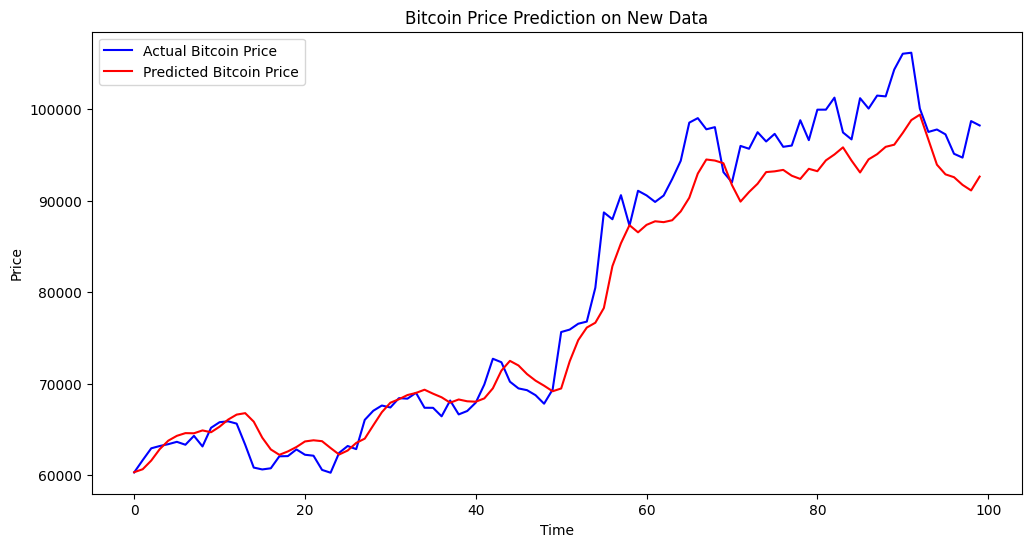

In [ ]:
# Ambil data baru dari Yahoo Finance
new_data = yf.download(ticker, start='2024-01-02', end='2024-12-31')
new_data.columns = new_data.columns.get_level_values(0)

# Preprocessing data baru
new_data['EMA'] = ta.EMA(new_data['Close'], timeperiod=100)
new_data['MA'] = ta.SMA(new_data['Close'], timeperiod=200)
new_data = new_data.dropna()
data_to_scale_new = new_data[['Close', 'EMA', 'MA']]
scaled_data_new = scaler.transform(data_to_scale_new)

# Membuat dataset untuk prediksi dengan data baru
X_new, y_new = create_dataset(scaled_data_new, sequence_length)

# Reshape input untuk LSTM
X_new = np.reshape(X_new, (X_new.shape[0], X_new.shape[1], X_new.shape[2]))

# Prediksi pada data baru
predicted_prices_new = model.predict(X_new)
predicted_prices_new_extended = np.zeros((predicted_prices_new.shape[0], 3))
predicted_prices_new_extended[:, 0] = predicted_prices_new[:, 0]

# Mengembalikan hasil prediksi ke skala asli
predicted_prices_new_original = scaler.inverse_transform(predicted_prices_new_extended)[:, 0]

# Mengembalikan y_new ke skala asli
y_new_extended = np.zeros((y_new.shape[0], 3))
y_new_extended[:, 0] = y_new
y_new_actual_original = scaler.inverse_transform(y_new_extended)[:, 0]

# Visualisasi hasil prediksi vs data aktual baru
plt.figure(figsize=(12,6))
plt.plot(y_new_actual_original, color='blue', label='Actual Bitcoin Price')
plt.plot(predicted_prices_new_original, color='red', label='Predicted Bitcoin Price')
plt.title('Bitcoin Price Prediction on New Data')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

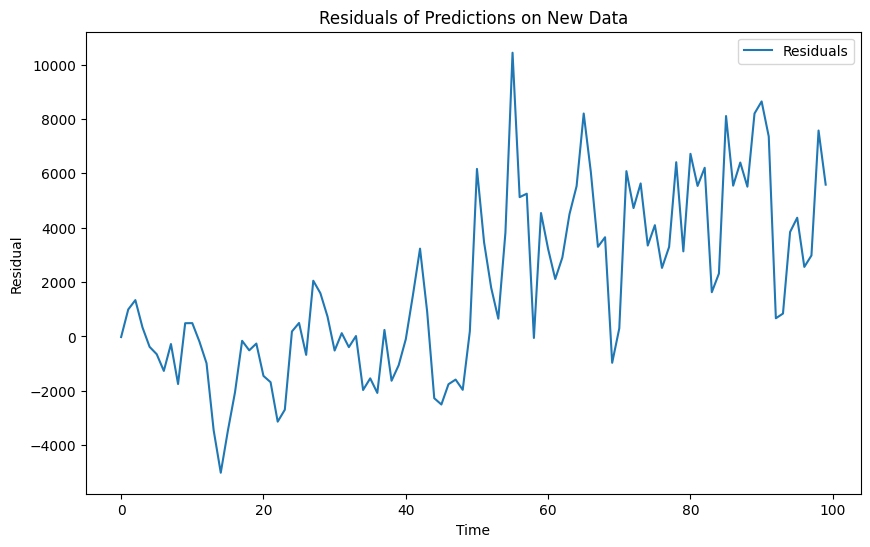

In [ ]:
# Analisis residual
residuals_new = y_new_actual_original - predicted_prices_new_original
plt.figure(figsize=(10,6))
plt.plot(residuals_new, label='Residuals')
plt.title('Residuals of Predictions on New Data')
plt.xlabel('Time')
plt.ylabel('Residual')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


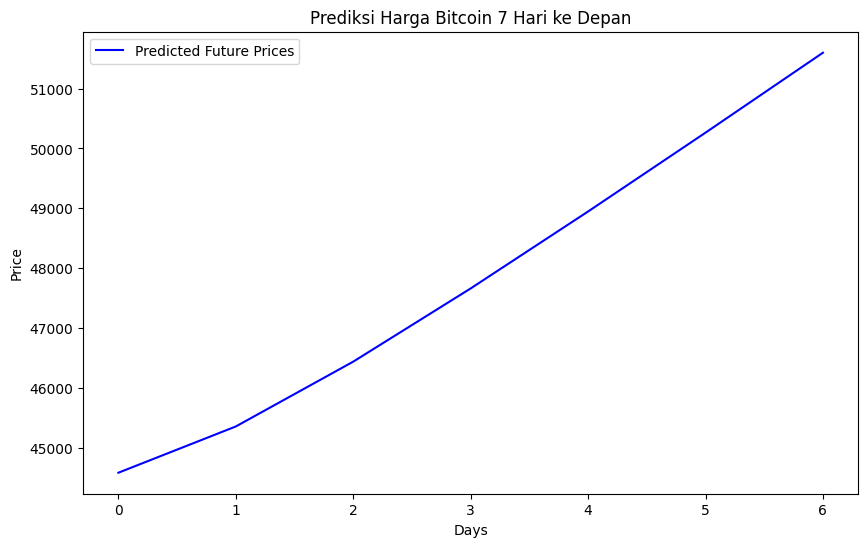

In [ ]:
last_sequence = scaled_data[-sequence_length:]
future_predictions = []
num_days_to_predict = 7

for _ in range(num_days_to_predict):
    if len(last_sequence.shape) != 3:
        last_sequence = np.reshape(last_sequence, (1, last_sequence.shape[0], last_sequence.shape[1]))
    predicted_price = model.predict(last_sequence)
    future_predictions.append(predicted_price[0][0])
    predicted_price_with_features = np.array([[predicted_price[0][0], last_sequence[0, -1, 1], last_sequence[0, -1, 2]]])
    predicted_price_with_features_reshaped = np.reshape(predicted_price_with_features, (1, 1, 3))
    new_sequence = np.append(last_sequence[:, 1:, :], predicted_price_with_features_reshaped, axis=1)
    last_sequence = new_sequence

# Membuat array dengan 3 kolom, mengisi kolom kedua dan ketiga dengan nilai 0
future_predictions_scaled = np.array(future_predictions).reshape(-1, 1)
future_predictions_scaled_extended = np.zeros((future_predictions_scaled.shape[0], 3))
future_predictions_scaled_extended[:, 0] = future_predictions_scaled[:, 0]

# Mengembalikan hasil prediksi ke skala asli
future_predictions_original = scaler.inverse_transform(future_predictions_scaled_extended)[:, 0]

plt.figure(figsize=(10, 6))
plt.plot(future_predictions_original, label='Predicted Future Prices', color='blue')
plt.title('Prediksi Harga Bitcoin 7 Hari ke Depan')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()


In [ ]:
# Menyimpan model ke file .h5
model.save('model_bitcoin.h5')

[*********************100%***********************]  1 of 1 completed


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step


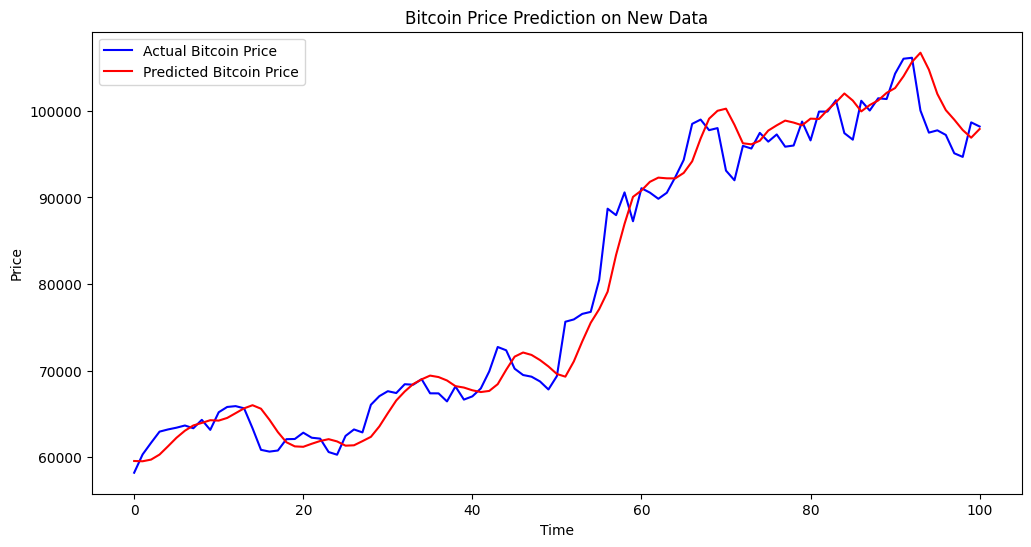

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
import talib as ta

# Function untuk mengambil data baru dan melakukan preprocessing
def get_preprocessed_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date)
    close_prices = data['Close'].values  # Mengubah kolom Close menjadi numpy.ndarray 1D
    if close_prices.ndim > 1:
        close_prices = close_prices.flatten()  # Memastikan input adalah array 1D
    data['EMA'] = ta.EMA(close_prices.astype(float), timeperiod=100)
    data['MA'] = ta.SMA(close_prices.astype(float), timeperiod=200)
    data = data.dropna()
    data_to_scale = data[['Close', 'EMA', 'MA']].values  # Mengubah menjadi numpy.ndarray
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data_to_scale)
    return scaled_data, scaler

# Mengambil data baru berdasarkan ticker dan jangka waktu prediksi
ticker = 'BTC-USD'
start_date = '2024-01-01'
end_date = '2024-12-31'
sequence_length = 60

scaled_data_new, scaler = get_preprocessed_data(ticker, start_date, end_date)

# Membuat dataset untuk prediksi
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_new, y_new = create_dataset(scaled_data_new, sequence_length)

# Reshape input untuk LSTM
X_new = np.reshape(X_new, (X_new.shape[0], X_new.shape[1], X_new.shape[2]))

# Memuat model yang disimpan
model = load_model('model_bitcoin.h5')

# Melakukan prediksi pada data baru
predicted_prices_new = model.predict(X_new)
predicted_prices_new_extended = np.zeros((predicted_prices_new.shape[0], 3))
predicted_prices_new_extended[:, 0] = predicted_prices_new[:, 0]

# Mengembalikan hasil prediksi ke skala asli
predicted_prices_new_original = scaler.inverse_transform(predicted_prices_new_extended)[:, 0]

# Mengembalikan y_new ke skala asli
y_new_extended = np.zeros((y_new.shape[0], 3))
y_new_extended[:, 0] = y_new
y_new_actual_original = scaler.inverse_transform(y_new_extended)[:, 0]

# Visualisasi hasil prediksi vs data aktual baru
plt.figure(figsize=(12,6))
plt.plot(y_new_actual_original, color='blue', label='Actual Bitcoin Price')
plt.plot(predicted_prices_new_original, color='red', label='Predicted Bitcoin Price')
plt.title('Bitcoin Price Prediction on New Data')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [ ]:
# Menghitung Mean Squared Error (MSE)
mse = mean_squared_error(y_new_actual_original, predicted_prices_new_original)

# Menghitung Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Menghitung Mean Absolute Error (MAE)
mae = mean_absolute_error(y_new_actual_original, predicted_prices_new_original)

# Menghitung Mean Absolute Percentage Error (MAPE)
mape = mean_absolute_percentage_error(y_new_actual_original, predicted_prices_new_original)

# Menghitung Akurasi
accuracy = 100 - (mape * 100)

print(f'Akurasi: {accuracy:.2f}%')
print(f'MAPE: {mape * 100:.2f}%')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Error (MAE): {mae}')


Akurasi: 97.37%
MAPE: 2.63%
Mean Squared Error (MSE): 7699290.168577234
Root Mean Squared Error (RMSE): 2774.7594794102847
Mean Absolute Error (MAE): 2087.6099946764734


In [ ]:
from google.colab import files

files.download('model_bitcoin.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>